In [1]:
from data_code.dataset_builder import build_dataset

import torch
import torch.nn as nn

In [2]:
int_emb = torch.load('data_code/INT_embeddings.pt')
rt_emb = torch.load('data_code/RT_embeddings.pt')
rn_emb = torch.load('data_code/RNaseH_embeddings.pt')
neg_emb = torch.load('data_code/negatives_embeddings.pt')
class_embeddings = {"INT": int_emb, "RT": rt_emb, "RN": rn_emb, "NEG": neg_emb}

train_loader, val_loader, class_weights, label_map = build_dataset(class_embeddings = class_embeddings, window_size= 64, stride = 16)

Label map: {'INT': 0, 'RT': 1, 'RN': 2, 'NEG': 3}
Train: 1418, Val: 353
Train distribution: {'INT': 95, 'RT': 1029, 'RN': 245, 'NEG': 49}
Class weights: {'INT': 1.17, 'RT': 0.108, 'RN': 0.454, 'NEG': 2.268}


In [3]:
class BioSequenceClassifier(nn.Module):
    def __init__(self):
        super(BioSequenceClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.model(x)

In [4]:
device = 'cuda'

In [5]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
model = BioSequenceClassifier().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01, weight_decay= 1e-5)
epochs = 20

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    num_samples = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = inputs.size(0)
        running_loss += loss.item() * batch_size
        num_samples += batch_size

    epoch_loss = running_loss / num_samples

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
                
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
    val_epoch_loss = val_loss / len(val_loader.dataset)
    val_acc = 100 * correct / total
        
    history['train_loss'].append(epoch_loss)
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_acc)
        
    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {epoch_loss:.4f} | "
                f"Val Loss: {val_epoch_loss:.4f} | "
                f"Val Acc: {val_acc:.2f}%")

Epoch 2/20 | Train Loss: 0.5142 | Val Loss: 0.3516 | Val Acc: 87.25%
Epoch 4/20 | Train Loss: 0.3259 | Val Loss: 0.2785 | Val Acc: 90.37%
Epoch 6/20 | Train Loss: 0.2626 | Val Loss: 0.2184 | Val Acc: 91.22%
Epoch 8/20 | Train Loss: 0.2345 | Val Loss: 0.1936 | Val Acc: 92.35%
Epoch 10/20 | Train Loss: 0.2059 | Val Loss: 0.1954 | Val Acc: 92.63%
Epoch 12/20 | Train Loss: 0.1904 | Val Loss: 0.2006 | Val Acc: 92.92%
Epoch 14/20 | Train Loss: 0.1961 | Val Loss: 0.1897 | Val Acc: 92.63%
Epoch 16/20 | Train Loss: 0.1924 | Val Loss: 0.1720 | Val Acc: 93.77%
Epoch 18/20 | Train Loss: 0.1625 | Val Loss: 0.1716 | Val Acc: 93.77%
Epoch 20/20 | Train Loss: 0.1458 | Val Loss: 0.2217 | Val Acc: 92.63%


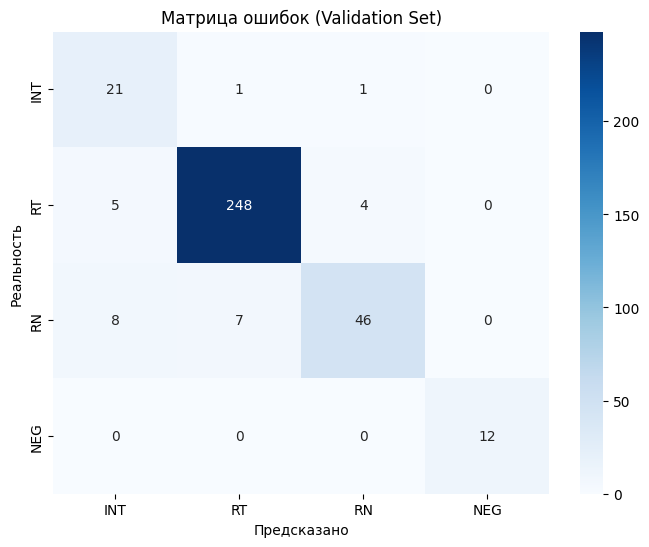

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(model, val_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    classes = ['INT', 'RT', 'RN', 'NEG']
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Предсказано')
    plt.ylabel('Реальность')
    plt.title('Матрица ошибок (Validation Set)')
    plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plot_confusion_matrix(model, val_loader, device)

In [ ]:
from data_code.annotated_processor import AnnotatedTokenLabeler

labeler = AnnotatedTokenLabeler()
